# 03 — `Echo.compare`: validation vs test

Three independent samples:

- **train**: reference sample. Used to fit `Echo`.
- **validation**: independent draw from the **same** distribution as train. Sanity check — `compare` should *not* reject uniformity of the p-values.
- **test**: draw from a **different** distribution (different marginal parameters and different correlation). `compare` should flag both the global p-value distribution and the per-component KS.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from echo import Echo
from echo.synthetic import make_sample


## Setup — train sample and fitted Echo

Train generator: 3 variables (`x` normal, `y` uniform, `z` normal), all with default `(0, 1)` parameters, latent correlation 0.5.

In [2]:
train_dists  = ['normal', 'uniform', 'normal']
train_params = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
train_rho    = 0.5

train        = make_sample(30_000, train_dists, parameters=train_params, correlation=train_rho, seed=1)

echo         = Echo()
z_train, _   = echo.train(train)

print('train shape:', train.shape)
print('train head:')
print(train.head(3).round(3))


train shape: (30000, 3)
train head:
       x      y      z
0  0.346  0.812  0.680
1 -1.303  0.553 -0.026
2 -0.537  0.593  0.197


## Validation — same distribution as train

Independent draw from the **same** generator (different seed).

In [3]:
validation = make_sample(
    10_000, train_dists,
    parameters  = train_params,
    correlation = train_rho,
    seed        = 2,
)

result_val = echo.compare(validation)

print('global:')
for k, v in result_val['global'].items():
    if hasattr(v, 'round'):
        print(f'  {k}:')
        print(v.round(4).to_string())
    else:
        print(f'  {k}: {round(v, 4)}')

print('\nmarginals (KS train vs validation per z_i):')
print(result_val['marginals'].round(4))


global:
  mean_p: 0.4962
  ks_stat_uniform: 0.0103
  ks_pvalue_uniform: 0.241
  frac_below_alpha:
0.01    0.0093
0.05    0.0508
0.10    0.1018

marginals (KS train vs validation per z_i):
    ks_stat  ks_pvalue
z0   0.0169     0.0273
z1   0.0119     0.2340
z2   0.0094     0.5184


Expected (under H0):

- `mean_p ≈ 0.5`
- `ks_pvalue_uniform` large (≫ 0.05)
- `frac_below_alpha[α] ≈ α`
- per-component KS p-values not concentrated near 0

## Test — different distribution

Different generator on every dimension:

- `x`: normal but with `mean = 1.5`, `std = 2.0` (train had `(0, 1)`).
- `y`: uniform on `(-2, 3)` (train had `(0, 1)`).
- `z`: normal with `mean = -0.5`, `std = 0.5` (train had `(0, 1)`).
- Correlation `-0.2` (train had `+0.5`).


In [4]:
test = make_sample(
    10_000, ['normal', 'uniform', 'normal'],
    parameters  = [(1.5, 2.0), (-2.0, 3.0), (-0.5, 0.5)],
    correlation = -0.2,
    seed        = 3,
)

result_test = echo.compare(test)

print('global:')
for k, v in result_test['global'].items():
    if hasattr(v, 'round'):
        print(f'  {k}:')
        print(v.round(4).to_string())
    else:
        print(f'  {k}: {round(v, 4)}')

print('\nmarginals (KS train vs test per z_i):')
print(result_test['marginals'].round(6))


global:
  mean_p: 0.0442
  ks_stat_uniform: 0.8641
  ks_pvalue_uniform: 0.0
  frac_below_alpha:
0.01    0.8735
0.05    0.8990
0.10    0.9119

marginals (KS train vs test per z_i):
     ks_stat  ks_pvalue
z0  0.249800        0.0
z1  0.405400        0.0
z2  0.522167        0.0


## Side-by-side comparison

In [5]:
summary = pd.DataFrame({
    'validation':  [
        result_val['global']['mean_p'],
        result_val['global']['ks_stat_uniform'],
        result_val['global']['ks_pvalue_uniform'],
        result_val['global']['frac_below_alpha'][0.05],
    ],
    'test':        [
        result_test['global']['mean_p'],
        result_test['global']['ks_stat_uniform'],
        result_test['global']['ks_pvalue_uniform'],
        result_test['global']['frac_below_alpha'][0.05],
    ],
}, index=['mean(p)', 'KS vs U(0,1)', 'p of KS', 'frac(p<0.05)'])
summary.round(6)


,validation,test
mean(p),0.496173,0.044151
"KS vs U(0,1)",0.010265,0.864084
p of KS,0.241044,0.000000
frac(p<0.05),0.050800,0.899000


### p-value histograms

Validation (same dist) → flat. Test (different dist) → strongly non-uniform with a peak in the low-p tail (events with high chi2 in the train's whitened space).

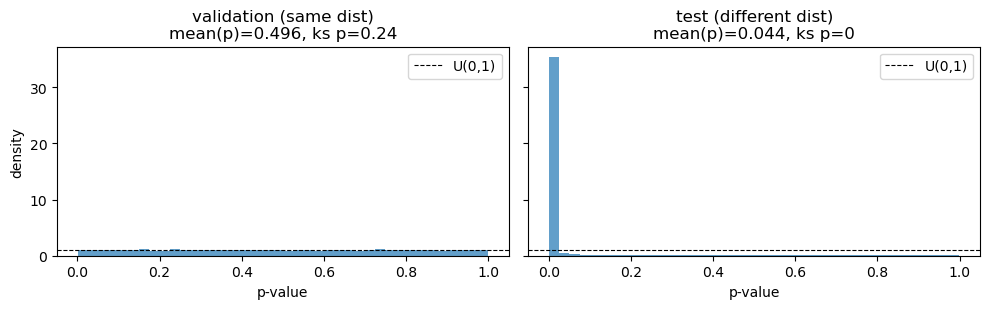

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (title, r) in zip(
    axes,
    [('validation (same dist)', result_val), ('test (different dist)', result_test)],
):
    ax.hist(r['p'], bins=40, density=True, alpha=0.7)
    ax.axhline(1.0, color='k', lw=0.8, ls='--', label='U(0,1)')
    g = r['global']
    ax.set_title(f"{title}\nmean(p)={g['mean_p']:.3f}, ks p={g['ks_pvalue_uniform']:.2g}")
    ax.set_xlabel('p-value')
    ax.legend()
axes[0].set_ylabel('density')
fig.tight_layout()


### Per-component KS

Under H0 the KS distances are small (sampling noise only); under H1 each whitened component picks up a sizeable distance, because the PCA rotation mixes the original variables and any global change propagates through.

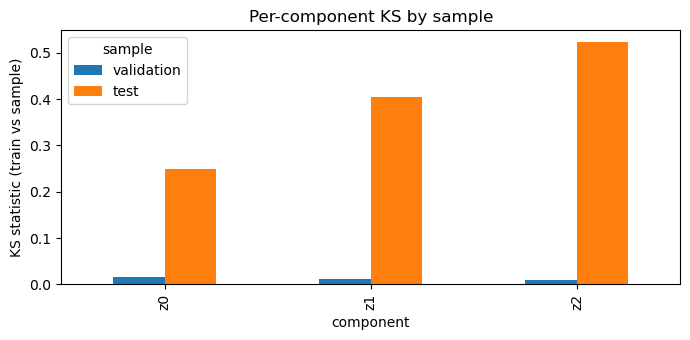

In [7]:
ks_table = pd.DataFrame({
    'validation': result_val['marginals']['ks_stat'],
    'test':       result_test['marginals']['ks_stat'],
})

ax = ks_table.plot(kind='bar', figsize=(7, 3.5))
ax.set_ylabel('KS statistic (train vs sample)')
ax.set_xlabel('component')
ax.set_title('Per-component KS by sample')
ax.legend(title='sample')
ax.figure.tight_layout()


### Marginals of `z` train vs sample

Visual confirmation.

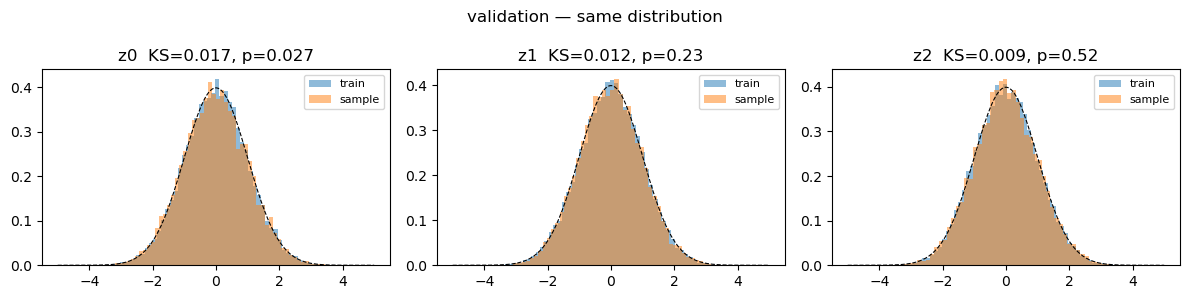

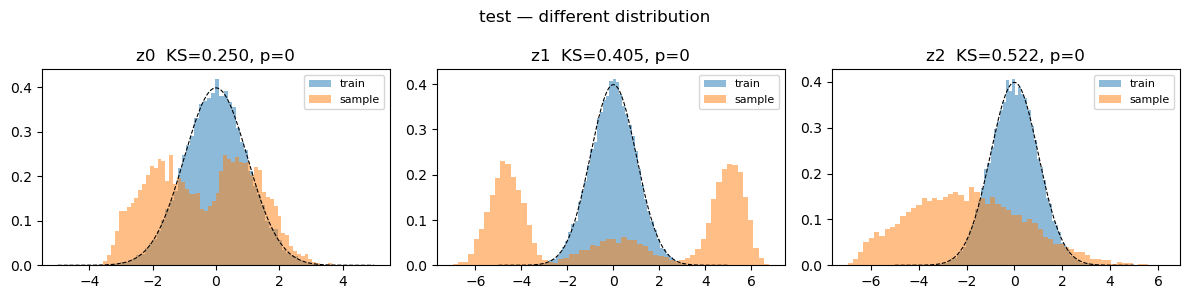

In [8]:
def plot_z_marginals(z_train, z_other, title, marginals):
    grid = np.linspace(-5, 5, 200)
    pdf  = norm.pdf(grid)

    fig, axes = plt.subplots(1, z_train.shape[1], figsize=(4 * z_train.shape[1], 3))
    fig.suptitle(title)
    for ax, col in zip(axes, z_train.columns):
        ax.hist(z_train[col], bins=60, alpha=0.5, density=True, label='train')
        ax.hist(z_other[col], bins=60, alpha=0.5, density=True, label='sample')
        ax.plot(grid, pdf, 'k--', lw=0.8)
        ks = marginals.loc[col]
        ax.set_title(f'{col}  KS={ks.ks_stat:.3f}, p={ks.ks_pvalue:.2g}')
        ax.legend(fontsize=8)
    fig.tight_layout()

plot_z_marginals(z_train, result_val['z'],  'validation — same distribution',      result_val['marginals'])
plot_z_marginals(z_train, result_test['z'], 'test — different distribution',       result_test['marginals'])
